In [1]:
library(Seurat)
library(tidyverse)
library(mclust)
library(ggplot2)
library(patchwork)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
# Pathes
input_path  <- "/nfs/home/students/f.mathis/SysBioMed-PLAs/data/datasets/"
output_path <- "/nfs/home/students/a.dersch/FoPra_PLAs/data/datasets_automated/"
BASE_OUT    <- "/nfs/home/students/a.dersch/FoPra_PLAs/results/gating_automation/"

QC_BASE <- "/nfs/home/students/a.dersch/FoPra_PLAs/results/sample_qc/"

if (!dir.exists(output_path)) dir.create(output_path, recursive = TRUE)

In [ ]:
#Preparation
all_lineages <- c("B cells", "DCs", "NK cells", "Unassigned", "CD4 T", "Macrophages", "Neutrophils", "CD8 T cells")

marker_aliases <- list(
  CD41  = c("ITGA2B", "CD41", "GPIIB"),
  CD42b = c("GP1BA", "CD42B", "GPIBA"),
  CD61  = c("ITGB3", "CD61", "GPIIIA"),
  CD62P = c("SELP", "CD62P", "PSELECTIN")
)

datasets_map <- list(
  #"gated_heart_processed.rds"        = "heart",
  #"gated_sepsis_processed.rds"       = "sepsis",
  "gated_vaccine_processed.rds"      = "vaccine"
  #"gated_ImmuneAging.rds"            = "immune_aging",
  #"gated_our_dataset_processed.rds"  = "our_data"
)
find_marker_name <- function(seurat_features, alias_list) {
  for (alias in alias_list) {
    query <- grep(paste0("^", alias, "(\\.|$)"), seurat_features, value = TRUE, ignore.case = TRUE)
    if (length(query) > 0) return(query[1])
  }
  return(NULL)
}

In [ ]:

for (file in names(datasets_map)) {
  dataset_type <- datasets_map[[file]]
  print(paste("Process:", dataset_type))

  seurat_obj <- tryCatch(readRDS(paste0(input_path, file)), error = function(e) {
    warning(paste("Datei nicht gefunden:", file)); return(NULL)
  })
  if (is.null(seurat_obj)) next
  
  DefaultAssay(seurat_obj) <- "ADT"
  all_features <- rownames(seurat_obj)
  
  seurat_obj$automative_gating_single <- "platelet-free"
  seurat_obj$automative_gating_double <- "platelet-free"
  
  qc_table_file <- paste0(QC_BASE, dataset_type, "/19_final_sample_lineage_QC_table.csv")
  
  trusted_pairs <- NULL
  if (file.exists(qc_table_file)) {
    print("-> Integriere finale Proben-QC-Tabelle...")
    kollege_qc <- read.csv(qc_table_file)
    
    trusted_pairs <- kollege_qc %>% 
      filter(final_pair_status == "trusted") %>%
      select(sample_id, celltype_id)
  } else {
    warning("-> Keine QC-Tabelle gefunden. Gating läuft ungefiltert!")
  }
  
  cd41_name <- find_marker_name(all_features, marker_aliases$CD41)
  cd61_name <- find_marker_name(all_features, marker_aliases$CD61)
  
  if (is.null(cd41_name)) {
    warning(paste("Überspringe", dataset_type, "da kein CD41-Marker existiert.")); next
  }
  
  for (lineage_name in all_lineages) {
    if (!(lineage_name %in% seurat_obj$lineage)) next
    
    Zellen_im_Zelltyp <- which(seurat_obj$lineage == lineage_name)
    if (length(Zellen_im_Zelltyp) < 50) next
    
    if (!is.null(trusted_pairs)) {
      cell_samples <- seurat_obj$sample[Zellen_im_Zelltyp] 
      
      valid_samples <- trusted_pairs %>% 
        filter(celltype_id == lineage_name) %>% 
        pull(sample_id)
      
      Zellen_im_Zelltyp <- Zellen_im_Zelltyp[cell_samples %in% valid_samples]
      
      if (length(Zellen_im_Zelltyp) < 20) {
        print(paste("   -> [QC Filter] Überspringe Lineage", lineage_name, "- Keine verlässlichen Spender übrig."))
        next
      }
    }
    
    # 1D GMM (CD41)
    cd41_values <- FetchData(seurat_obj, vars = cd41_name)[Zellen_im_Zelltyp, 1]
    gmm_cd41 <- tryCatch(Mclust(cd41_values, G = 2), error = function(e) NULL)
    
    if (!is.null(gmm_cd41)) {
      thresh_cd41 <- max(cd41_values[gmm_cd41$classification == 1])
      seurat_obj$automative_gating_single[Zellen_im_Zelltyp] <- ifelse(cd41_values > thresh_cd41, "PLA", "platelet-free")
    }
    
    # 2D GMM (CD41 + CD61)
    if (!is.null(cd61_name)) {
      cd61_values <- FetchData(seurat_obj, vars = cd61_name)[Zellen_im_Zelltyp, 1]
      gmm_cd61 <- tryCatch(Mclust(cd61_values, G = 2), error = function(e) NULL)
      
      if (!is.null(gmm_cd61) && !is.null(gmm_cd41)) {
        thresh_cd61 <- max(cd61_values[gmm_cd61$classification == 1])
        seurat_obj$automative_gating_double[Zellen_im_Zelltyp] <- ifelse((cd41_values > thresh_cd41) & (cd61_values > thresh_cd61), "PLA", "platelet-free")
      }
    } else {
      seurat_obj$automative_gating_double[Zellen_im_Zelltyp] <- "CD61_missing"
    }
  }
  
  neuer_name <- paste0(dataset_type, "_automated_gating.rds")
  saveRDS(seurat_obj, file = paste0(output_path, "/", neuer_name))
  print(paste("-> Datensatz erfolgreich prozessiert und gespeichert als:", neuer_name))
}

[1] "Process: vaccine"
[1] "-> Integriere finale Proben-QC-Tabelle..."
[1] "   -> [QC Filter] Überspringe Lineage Unassigned - Keine verlässlichen Spender übrig."
[1] "   -> [QC Filter] Überspringe Lineage Neutrophils - Keine verlässlichen Spender übrig."
[1] "-> Datensatz erfolgreich prozessiert und gespeichert als: vaccine_automated_gating.rds"


In [47]:
input_path <- "/nfs/home/students/f.mathis/SysBioMed-PLAs/data/datasets/"
output_path <- "/nfs/home/students/a.dersch/FoPra_PLAs/data/datasets"
OUT_DIR <- "/nfs/home/students/a.dersch/FoPra_PLAs/results/gating_automation/"

all_lineages <- c("B cells", "DCs", "NK cells", "Unassigned", "CD4 T", "Macrophages", "Neutrophils", "CD8 T cells")
# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
datasets <- c("gated_heart_processed.rds")
# "immune_aging", "heart", "sepsis", "vaccine", "our_data"
dataset_type <- "heart"

cd41_name <- "ITGA2B.1"
cd61_name <- "ITGB3.1"

In [9]:
for (file in datasets) {
  print(paste("Verarbeite Datensatz:", file))
  seurat_obj <- readRDS(paste0(input_path, file))
  DefaultAssay(seurat_obj) <- "ADT"
  
  seurat_obj$automative_gating_single <- "platelet-free"
  seurat_obj$automative_gating_double <- "platelet-free"
  
  for (lineage_name in all_lineages) {
    
    if (!(lineage_name %in% seurat_obj$lineage)) next
    
    Zellen_im_Zelltyp <- which(seurat_obj$lineage == lineage_name)
    
    if (length(Zellen_im_Zelltyp) < 50) {
      print(paste("-> Überspringe Lineage", lineage_name, "aufgrund zu geringer Zellzahl:", length(Zellen_im_Zelltyp)))
      next
    }
    
    cd41_values <- FetchData(seurat_obj, vars = cd41_name)[Zellen_im_Zelltyp, 1]
    cd61_values <- FetchData(seurat_obj, vars = cd61_name)[Zellen_im_Zelltyp, 1]
    
    # CD41 GMM 
    gmm_cd41 <- tryCatch(Mclust(cd41_values, G = 2), error = function(e) NULL)
    if (is.null(gmm_cd41)) next
    thresh_cd41 <- max(cd41_values[gmm_cd41$classification == 1])
    
    # CD61 GMM f
    gmm_cd61 <- tryCatch(Mclust(cd61_values, G = 2), error = function(e) NULL)
    if (is.null(gmm_cd61)) next
    thresh_cd61 <- max(cd61_values[gmm_cd61$classification == 1])
    
    # Single Gate (Nur CD41)
    seurat_obj$automative_gating_single[Zellen_im_Zelltyp] <- ifelse(cd41_values > thresh_cd41, "PLA", "platelet-free")

    # Double Gate (CD41 + CD61)
    seurat_obj$automative_gating_double[Zellen_im_Zelltyp] <- ifelse((cd41_values > thresh_cd41) & (cd61_values > thresh_cd61), "PLA", "platelet-free")
  }
  
  neuer_name <- str_replace(file, "\\.rds", "_V2.rds")
  saveRDS(seurat_obj, file = paste0(output_path, "/", neuer_name))
  print(paste("Erfolgreich gespeichert als:", neuer_name))
}

[1] "Verarbeite Datensatz: gated_heart_processed.rds"
[1] "-> Überspringe Lineage CD8 T cells aufgrund zu geringer Zellzahl: 13"
[1] "Erfolgreich gespeichert als: gated_heart_processed_V2.rds"


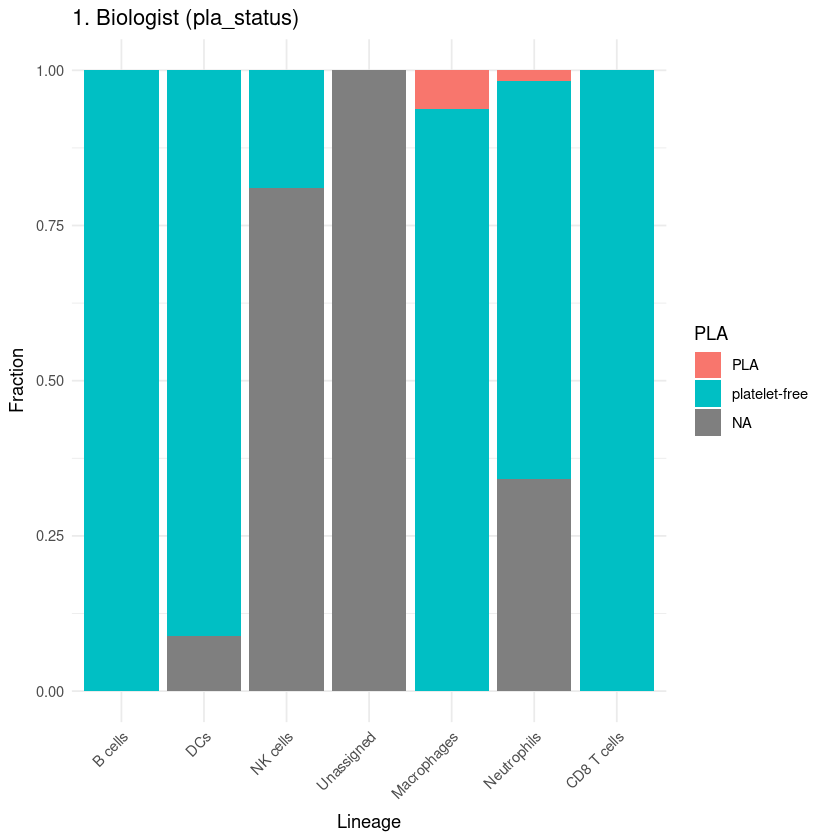

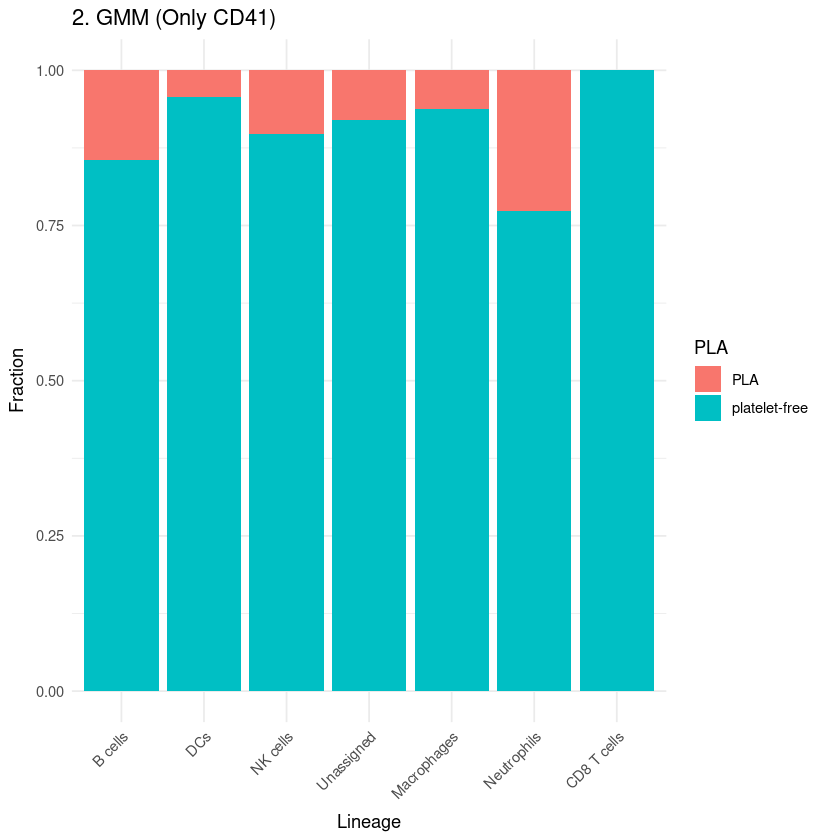

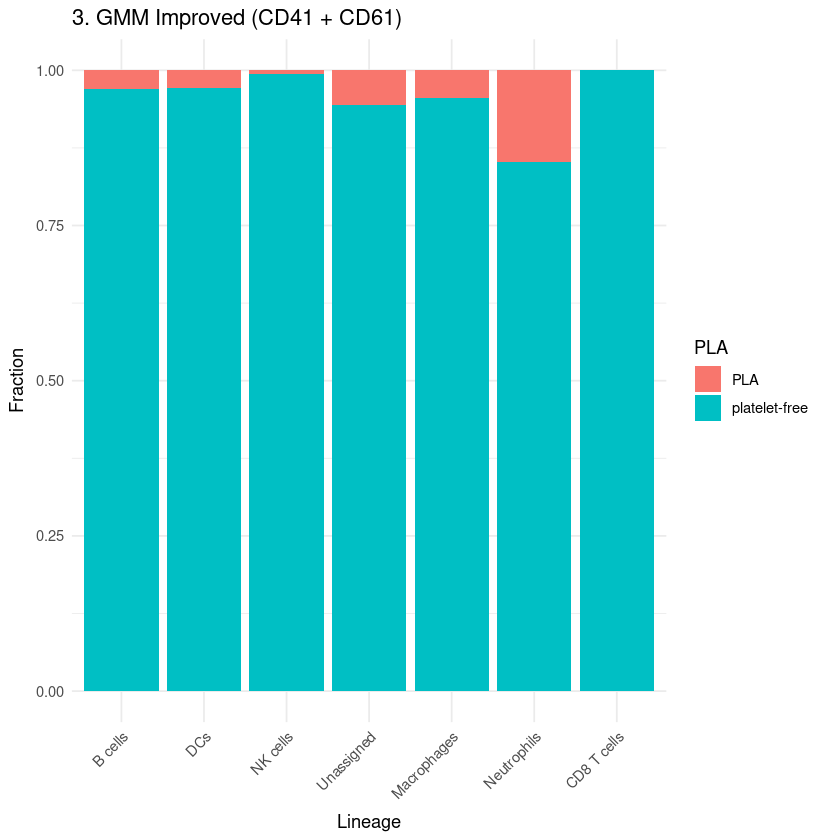

In [ ]:
seurat_plot <- readRDS(paste0(output_path, "/gated_heart_processed_V2.rds"))
plot_data <- seurat_plot@meta.data %>% filter(lineage %in% all_lineages)

p1 <- ggplot(plot_data, aes(x = lineage, fill = pla_status)) +
  geom_bar(position = "fill") +
  theme_minimal() +
  labs(title = "1. Biologist (pla_status)", x = "Lineage", y = "Fraction", fill = "PLA") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p2 <- ggplot(plot_data, aes(x = lineage, fill = automative_gating_single)) +
  geom_bar(position = "fill") +
  theme_minimal() +
  labs(title = "2. GMM (Only CD41)", x = "Lineage", y = "Fraction", fill = "PLA") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p3 <- ggplot(plot_data, aes(x = lineage, fill = automative_gating_double)) +
  geom_bar(position = "fill") +
  theme_minimal() +
  labs(title = "3. GMM Improved (CD41 + CD61)", x = "Lineage", y = "Fraction", fill = "PLA") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p1)
print(p2)
print(p3)

ggsave(paste0(OUT_DIR, "barplot_pla_fraction_biologist_", dataset_type, ".png"), 
       plot = p1, width = 8, height = 6, dpi = 300)
ggsave(paste0(OUT_DIR, "barplot_pla_fraction_gmm_1d_", dataset_type, ".png"), 
       plot = p2, width = 8, height = 6, dpi = 300)
ggsave(paste0(OUT_DIR, "barplot_pla_fraction_gmm_2d_", dataset_type, ".png"), 
       plot = p3, width = 8, height = 6, dpi = 300)

In [32]:
OUT_DIR <- "/nfs/home/students/a.dersch/FoPra_PLAs/results/gating_automation/"
if (!dir.exists(OUT_DIR)) dir.create(OUT_DIR, recursive = TRUE)

seurat_plot <- readRDS(paste0(output_path, "/gated_heart_processed_V2.rds"))

print(names(seurat_plot@reductions))
print(colnames(seurat_plot@meta.data))
print(head(Embeddings(seurat_plot, "ADT_umap")))


[1] "GEX_pca"      "GEX_umap"     "ADT_pca"      "ADT_umap"     "wnn.umap"    
[6] "totalVI"      "umap_totalVI"
 [1] "orig.ident"               "nCount_RNA"              
 [3] "nFeature_RNA"             "nCount_ADT"              
 [5] "nFeature_ADT"             "sample"                  
 [7] "percent.mt"               "percent.ribo"            
 [9] "percent.hb"               "mt_outlier_all"          
[11] "is_outlier_RNA"           "is_outlier_protein"      
[13] "is_outlier"               "scDblFinder.class"       
[15] "scDblFinder.score"        "celltype"                
[17] "HF.etiology"              "Race"                    
[19] "Sex"                      "Age"                     
[21] "RNA_snn_res.0.8"          "seurat_clusters"         
[23] "RNA_snn_res.0.25"         "RNA.weight"              
[25] "ADT.weight"               "leiden_0.8_totalVI"      
[27] "leiden_0.25_totalVI"      "celltype_full"           
[29] "lineage"                  "pla_status"              
[3

In [56]:
reduction <- "ADT_umap"
Key(seurat_plot[["ADT_umap"]]) <- "adt_umap_"

# ----------------------------------------------------------------------
# PLOT 1: Die Referenz-UMAP (Zelltypen)
# ----------------------------------------------------------------------
png(paste0(OUT_DIR, "1_Reference_Lineage_", dataset_type, "_", reduction,".png"), 1200, 800)
# Wichtig: Wir nutzen reduction="umap_adt" (oder "umap"), je nachdem wie es berechnet wurde
print(DimPlot(seurat_plot, group.by="lineage", reduction = reduction, label=TRUE, repel=TRUE) + 
        labs(title="Reference Lineage Gating (Heart Dataset)"))
dev.off()

# ----------------------------------------------------------------------
# PLOT 2: UMAP eingefärbt nach dem originalen Gating der Biologin
# ----------------------------------------------------------------------
png(paste0(OUT_DIR, "2_Biologist_Gating_", dataset_type, "_", reduction,".png"), 1200, 800)
print(DimPlot(seurat_plot, group.by="pla_status", reduction = reduction) + 
        scale_color_manual(values = c("PLA" = "#F8766D", "platelet-free" = "#00BFC4", "NA" = "grey70")) +
        labs(title="PLA Status - Biologist Gating (Manual)"))
dev.off()

# ----------------------------------------------------------------------
# PLOT 3: UMAP eingefärbt nach deinem 1D-GMM (Nur CD41)
# ----------------------------------------------------------------------
png(paste0(OUT_DIR, "3_GMM_Single_Gating_", dataset_type, "_", reduction,".png"), 1200, 800)
print(DimPlot(seurat_plot, group.by="automative_gating_single", reduction = reduction) + 
        scale_color_manual(values = c("PLA" = "#F8766D", "platelet-free" = "#00BFC4")) +
        labs(title="PLA Status - Automated 1D GMM (CD41 only)"))
dev.off()

# ----------------------------------------------------------------------
# PLOT 4: UMAP eingefärbt nach deinem verbesserten 2D-GMM (CD41 + CD61)
# ----------------------------------------------------------------------
png(paste0(OUT_DIR, "4_GMM_Double_Gating_", dataset_type, "_", reduction,".png"), 1200, 800)
print(DimPlot(seurat_plot, group.by="automative_gating_double", reduction = reduction) + 
        scale_color_manual(values = c("PLA" = "#F8766D", "platelet-free" = "#00BFC4")) +
        labs(title="PLA Status - Improved 2D GMM (CD41 + CD61)"))
dev.off()

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from adt_umap_ to adtumap_”


agg_record_19bace12a67eaf 
                        2

agg_record_19bace12a67eaf 
                        2

agg_record_19bace12a67eaf 
                        2

agg_record_19bace12a67eaf 
                        2

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


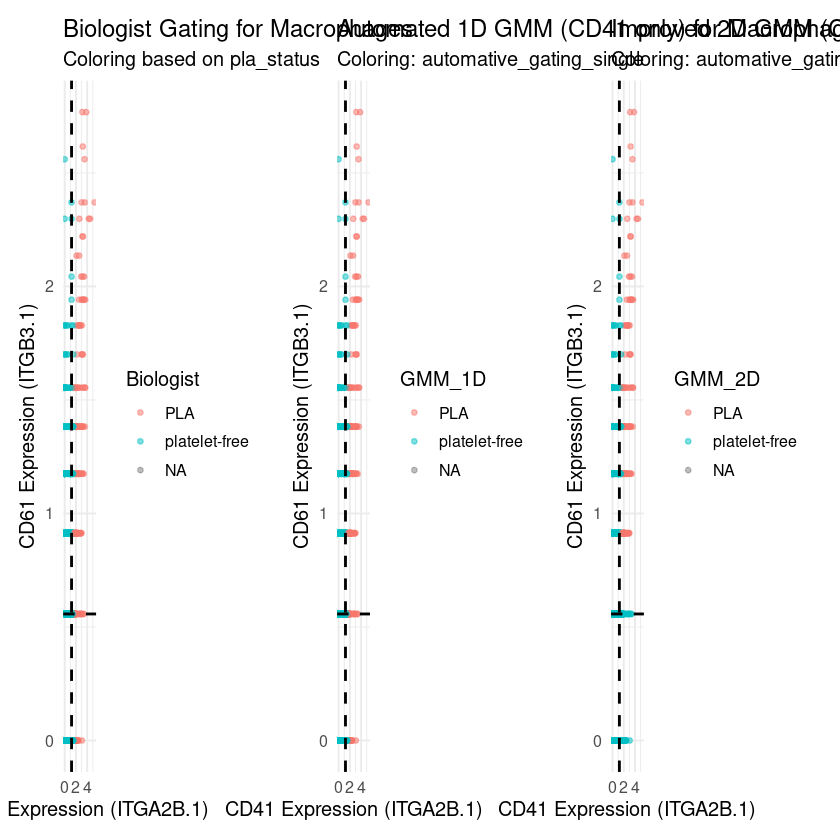

In [55]:
df_all <- FetchData(seurat_plot, vars = c("ITGA2B.1", "ITGB3.1", "pla_status", "automative_gating_single", "automative_gating_double", "lineage"))

# Specify lineage
lineage_oI <- "Macrophages"
df_2d <- df_all[df_all$lineage == lineage_oI, c("ITGA2B.1", "ITGB3.1", "pla_status", "automative_gating_single", "automative_gating_double")]
colnames(df_2d) <- c("CD41", "CD61", "Biologist", "GMM_1D", "GMM_2D")

base_lines <- list(
  geom_point(alpha = 0.5, size = 1.2),
  geom_vline(xintercept = thresh_cd41, linetype = "dashed", color = "black", size = 0.8),
  geom_hline(yintercept = thresh_cd61, linetype = "dashed", color = "black", size = 0.8),
  theme_minimal(base_size = 12),
  labs(x = "CD41 Expression (ITGA2B.1)", y = "CD61 Expression (ITGB3.1)")
)

# Plot A: Biologin
p_biologist <- ggplot(df_2d, aes(x = CD41, y = CD61, color = Biologist)) +
  base_lines +
  scale_color_manual(values = c("PLA" = "#F8766D", "platelet-free" = "#00BFC4", "NA" = "grey70")) +
  labs(title = paste0("Biologist Gating for ", lineage_oI), subtitle = "Coloring based on pla_status")

# Plot B: 1D GMM (CD41)
p_1d <- ggplot(df_2d, aes(x = CD41, y = CD61, color = GMM_1D)) +
  base_lines +
  scale_color_manual(values = c("PLA" = "#F8766D", "platelet-free" = "#00BFC4")) +
  labs(title = paste0("Automated 1D GMM (CD41 only) for ", lineage_oI), subtitle = "Coloring: automative_gating_single")

# Plot C: 2D GMM (CD41 + CD61)
p_2d <- ggplot(df_2d, aes(x = CD41, y = CD61, color = GMM_2D)) +
  base_lines +
  scale_color_manual(values = c("PLA" = "#F8766D", "platelet-free" = "#00BFC4")) +
  labs(title = paste0("Improved 2D GMM (CD41 + CD61) for ", lineage_oI), subtitle = "Coloring: automative_gating_double")

# Zusammenfügen mit patchwork und speichern
p_final_comparison <- p_biologist + p_1d + p_2d
print(p_final_comparison)
#print(p_biologist)
#print(p_1d)
#print(p_2d)

ggsave(paste0(OUT_DIR, "2d_gating_three_way_comparison_", dataset_type, "_", lineage_oI, ".png"), 
       plot = p_final_comparison, width = 18, height = 5, dpi = 300)

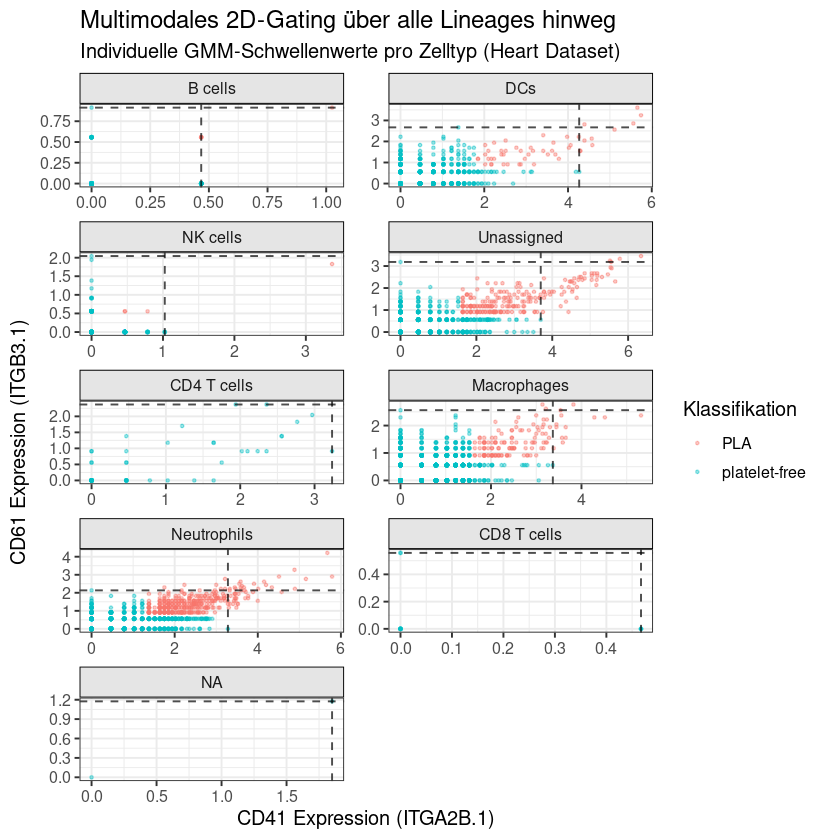

In [ ]:
library(Seurat)
library(ggplot2)
library(dplyr)

# 1. Daten für ALLE Zellen extrahieren
df_all_lineages <- FetchData(seurat_plot, vars = c("ITGA2B.1", "ITGB3.1", "lineage", "automative_gating_double"))
colnames(df_all_lineages) <- c("CD41", "CD61", "Lineage", "GMM_2D")

# 2. Da wir pro Lineage unterschiedliche Thresholds hatten, berechnen wir kurz 
# eine Hilfstabelle für die gestrichelten Linien im Plot
# (Nutzt die Daten, um die maximalen Werte der 'negativen' Zellen pro Gruppe zu finden)
df_thresholds <- df_all_lineages %>%
  filter(GMM_2D == "platelet-free") %>%
  group_by(Lineage) %>%
  summarise(
    thresh_cd41 = max(CD41, na.rm = TRUE),
    thresh_cd61 = max(CD61, na.rm = TRUE)
  )

# 3. Der Master-Plot mit Faceting
p_facets <- ggplot(df_all_lineages, aes(x = CD41, y = CD61, color = GMM_2D)) +
  geom_point(alpha = 0.4, size = 0.6) +
  # Hier passiert die Magie: Zeichne die individuellen Linien pro Kachel
  geom_vline(data = df_thresholds, aes(xintercept = thresh_cd41), linetype = "dashed", color = "black", alpha = 0.7) +
  geom_hline(data = df_thresholds, aes(yintercept = thresh_cd61), linetype = "dashed", color = "black", alpha = 0.7) +
  # Teilt den Plot vollautomatisch in Kacheln auf (2 Spalten)
  facet_wrap(~Lineage, ncol = 2, scales = "free") + 
  scale_color_manual(values = c("PLA" = "#F8766D", "platelet-free" = "#00BFC4")) +
  theme_bw(base_size = 12) +
  labs(
    title = "Multimodales 2D-Gating über alle Lineages hinweg",
    subtitle = "Individuelle GMM-Schwellenwerte pro Zelltyp (Heart Dataset)",
    x = "CD41 Expression (ITGA2B.1)", 
    y = "CD61 Expression (ITGB3.1)",
    color = "Klassifikation"
  ) +
  theme(strip.background = element_rect(fill = "grey90", color = "black"))

# Plot im Notebook anzeigen
print(p_facets)

# Als hochauflösendes Bild speichern
ggsave(paste0(OUT_DIR, "5_all_lineages_2d_gating_facets_", dataset_type, ".png"), plot = p_facets, width = 12, height = 16, dpi = 300)